# Notebook 05 — Perbandingan Antar Varian

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/05_comparison.ipynb)

**Anggota yang menggabungkan:** _Wendy_

---

Notebook ini **membaca file CSV history** yang sudah dihasilkan oleh keempat varian (file ada di folder `results/`), lalu menggabungkannya menjadi tabel ringkasan dan grafik komparatif.

**Prasyarat:** keempat anggota sudah commit notebook varian masing-masing dan file `results/*.csv` sudah ada di repo.

## 1. Setup

In [ ]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-sawit-supremacy.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 27 (delta 5), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (27/27), 21.02 KiB | 2.63 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = 'results'
files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith('.csv')])
print('Ditemukan file:', files)


Ditemukan file: ['01_single_layer.csv', '02_mlp_sigmoid.csv', '03_mlp_tanh.csv', '04_mlp_relu.csv']


## 2. Gabungkan semua history

In [ ]:
dfs = []
for f in files:
    df = pd.read_csv(os.path.join(RESULTS_DIR, f))
    dfs.append(df)
all_history = pd.concat(dfs, ignore_index=True)
all_history.head()


,accuracy,loss,val_accuracy,val_loss,epoch,variant
0,0.21875,2.083679,0.166667,1.998502,1,01_single_layer
1,0.21875,2.030791,0.166667,1.954946,2,01_single_layer
2,0.21875,1.978927,0.166667,1.911913,3,01_single_layer
3,0.21875,1.927821,0.125000,1.869472,4,01_single_layer
4,0.21875,1.877537,0.125000,1.827682,5,01_single_layer


## 3. Tabel akurasi akhir per varian

In [ ]:
final = all_history.sort_values('epoch').groupby('variant').tail(1)
summary = final[['variant', 'loss', 'val_loss', 'accuracy', 'val_accuracy']]
summary = summary.sort_values('val_accuracy', ascending=False).reset_index(drop=True)
summary


,variant,loss,val_loss,accuracy,val_accuracy
0,03_mlp_tanh,0.113794,0.126471,0.968750,0.958333
1,04_mlp_relu,0.034608,0.080660,0.989583,0.958333
2,02_mlp_sigmoid,0.251070,0.308569,0.916667,0.958333
3,01_single_layer,0.416680,0.543707,0.864583,0.750000


## 4. Plot validation accuracy semua varian

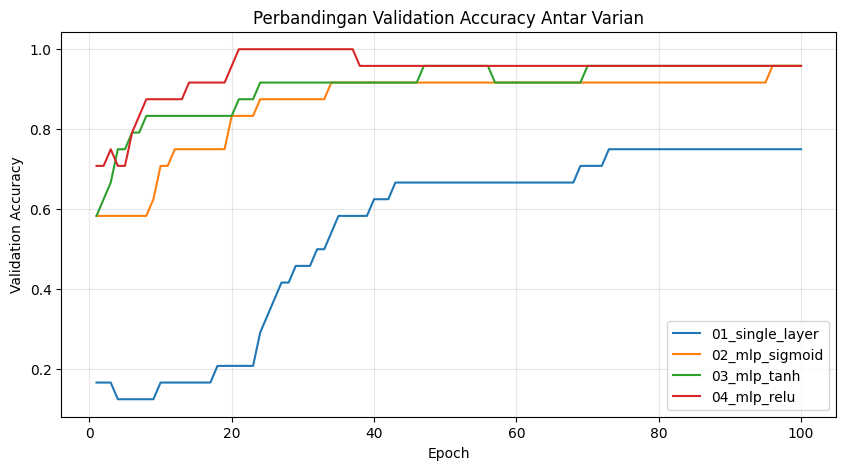

In [ ]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_accuracy'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Perbandingan Validation Accuracy Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Plot validation loss semua varian

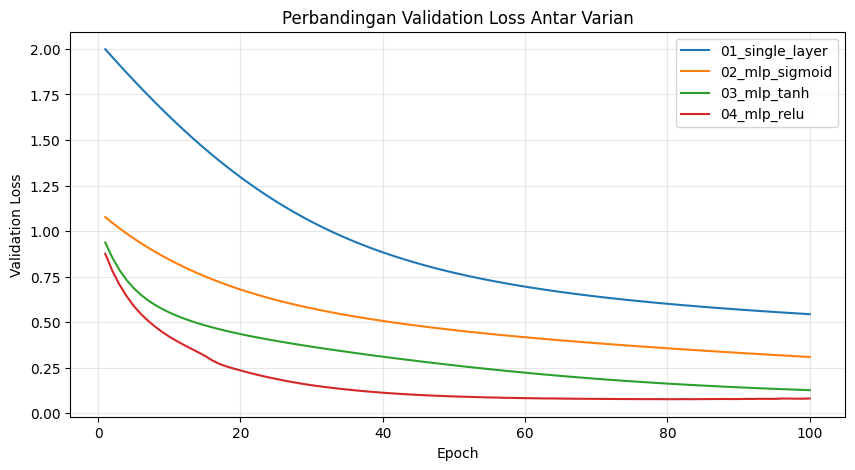

In [ ]:
plt.figure(figsize=(10, 5))
for variant, df in all_history.groupby('variant'):
    plt.plot(df['epoch'], df['val_loss'], label=variant)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Perbandingan Validation Loss Antar Varian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Diskusi kelompok
Berdasarkan tabel dan grafik di atas, **isi `docs/REPORT.md`** dengan analisis kelompok. Jangan hanya mendeskripsikan grafik — kaitkan dengan teori di slide kuliah.